### **Import the Libraries**

Now, let's import all the stuff we need.

In [2]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_scheduler
from datasets import load_dataset
from torch.utils.data import DataLoader
import evaluate
from tqdm.auto import tqdm

/home/vlad/CVUT/bi-pyt/AI-CleanChat/new_env/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Set Up the Device**

Let's check if we have a GPU available (faster training!). If not, we'll stick with the CPU.

In [3]:
# Use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Free up unused cached memory
if device == 'cuda':
    torch.cuda.empty_cache()

### **Load the Dataset**

We'll be using the `hate_speech_offensive` dataset, which is perfect for our classification task.

In [5]:
dataset = load_dataset('hate_speech_offensive')

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['count', 'hate_speech_count', 'offensive_language_count', 'neither_count', 'class', 'tweet'],
        num_rows: 24783
    })
})

### **Preprocess the Data**

Let's prepare the data. We'll extract the tweets and their corresponding classes.

In [7]:
# Preprocess the dataset to get texts and labels
def preprocess_function(examples):
    texts = examples['tweet']
    labels = examples['class']
    return {'text': texts, 'labels': labels}

dataset = dataset.map(preprocess_function, batched=True)

### **Split the Dataset**

We'll split the dataset into training and validation sets. Keeping 10% for validation sounds about right.

In [8]:
# Split the dataset: 90% train, 10% validation
dataset = dataset['train'].train_test_split(test_size=0.1)
train_dataset = dataset['train']
validation_dataset = dataset['test']

### **Initialize the Tokenizer**

We're going to use BERT's tokenizer since we're working with a BERT model.

In [9]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

### **Tokenize the Datasets**

Let's tokenize our text data. We'll set a max length to keep things consistent (that's should be OK for our chat app, chat messages often really short).

In [10]:
# Tokenize the text data
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
validation_dataset = validation_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 2479/2479 [00:01<00:00, 2164.25 examples/s]


### **Prepare the Data for PyTorch**

We'll format our datasets so that PyTorch can work with them seamlessly.

In [11]:
# Format datasets for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
validation_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

### **Load the Pre-trained BERT Model**

We're using the `bert-base-uncased` model. It's a good balance between performance and size—not too heavy to train.

In [12]:
# Load the pre-trained BERT model for sequence classification
num_labels = 3  # We have three classes to predict
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### **Prepare DataLoaders**

DataLoaders help us handle batching and shuffling. We'll set a batch size that balances speed and memory usage.

In [13]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
eval_dataloader = DataLoader(validation_dataset, batch_size=4)


### **Set Up the Optimizer and Scheduler**

We'll use the AdamW optimizer, which is standard for training transformers. The learning rate is set to a small value to ensure stable training.

In [14]:
# Set up the optimizer and learning rate scheduler
optimizer = AdamW(model.parameters(), lr=5e-5)
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    name='linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

/home/vlad/CVUT/bi-pyt/AI-CleanChat/new_env/lib64/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


### **Training Loop**

Time to train the model! We'll loop over the epochs and update the model's weights based on the loss.

In [15]:
import matplotlib.pyplot as plt # just to visualize how the loss decreases over time during training.

# Initialize lists to store loss and accuracy
avg_train_losses = []
avg_val_losses = []
validation_accuracies = []

In [16]:
# Load accuracy metric
from evaluate import load
metric = load('accuracy')

In [17]:
# Training and validation loop
model.train()
for epoch in range(num_epochs):
    train_losses = []
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}  # Move batch to device
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        train_losses.append(loss.item())
        progress_bar.set_postfix({'loss': loss.item()})

    # Average training loss
    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_train_losses.append(avg_train_loss)
    print(f'Average training loss for epoch {epoch+1}: {avg_train_loss}')

    # Validation loop
    model.eval()
    val_losses = []
    metric = load('accuracy')

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            # Validation loss
            loss = outputs.loss
            val_losses.append(loss.item())

            # Validation accuracy
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            metric.add_batch(predictions=predictions, references=batch['labels'])

    # Average validation loss
    avg_val_loss = sum(val_losses) / len(val_losses)
    avg_val_losses.append(avg_val_loss)
    print(f'Average validation loss for epoch {epoch+1}: {avg_val_loss}')

    # Validation accuracy
    eval_results = metric.compute()
    validation_accuracy = eval_results['accuracy']
    validation_accuracies.append(validation_accuracy)
    print(f'Validation Accuracy after epoch {epoch+1}: {validation_accuracy}')

    model.train()  # Switch back to training mode



Epoch 1/3: 100%|██████████| 2788/2788 [31:24<00:00,  1.48it/s, loss=0.371]  


Average training loss for epoch 1: 0.3126642674580484
Average validation loss for epoch 1: 0.26932602740613926
Validation Accuracy after epoch 1: 0.9148850342880194


Epoch 2/3: 100%|██████████| 2788/2788 [31:21<00:00,  1.48it/s, loss=0.0774] 


Average training loss for epoch 2: 0.2254965088969575
Average validation loss for epoch 2: 0.2658973177016202
Validation Accuracy after epoch 2: 0.9108511496571198


Epoch 3/3: 100%|██████████| 2788/2788 [31:19<00:00,  1.48it/s, loss=0.0329] 


Average training loss for epoch 3: 0.16667630366558125
Average validation loss for epoch 3: 0.2771080609598768
Validation Accuracy after epoch 3: 0.9072206534893102


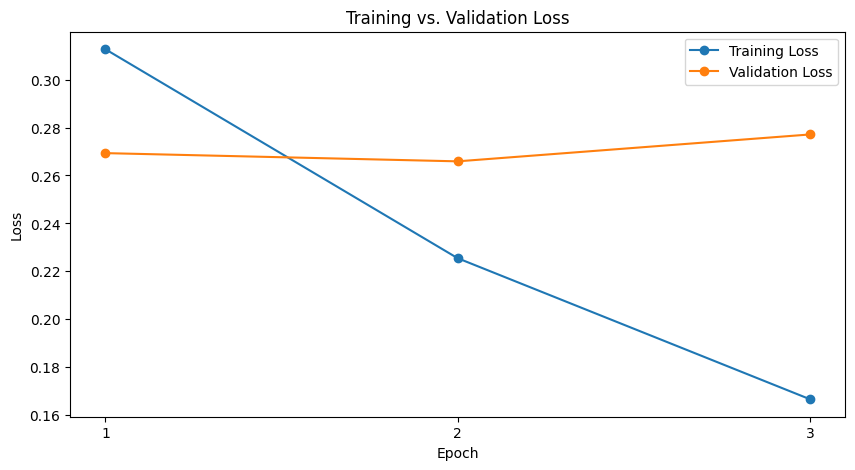

In [18]:
# Plot the training and validation loss per epoch
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), avg_train_losses, marker='o', label='Training Loss')
plt.plot(range(1, num_epochs+1), avg_val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.xticks(range(1, num_epochs+1))
plt.legend()
plt.show()

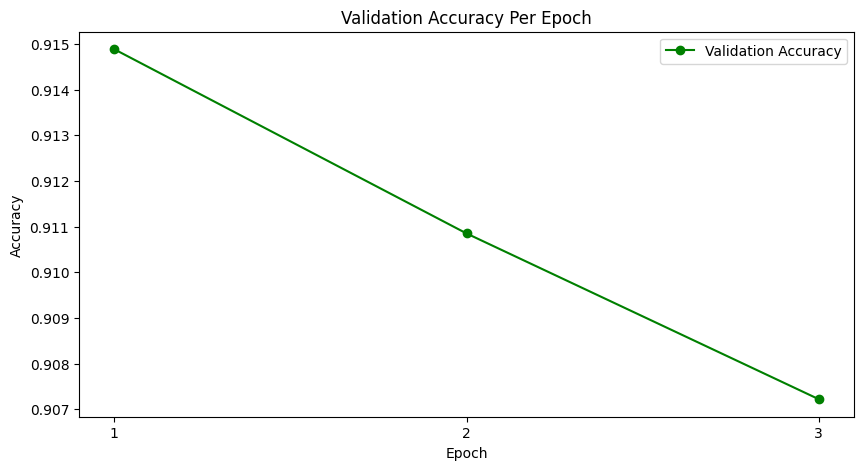

In [19]:
# Optional: Plot validation accuracy per epoch
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), validation_accuracies, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch')
plt.xticks(range(1, num_epochs+1))
plt.legend()
plt.show()

### **Evaluation Loop**

After training, we'll see how well the model performs on the validation set.

In [21]:
    # Evaluate on validation set
    model.eval()
    val_losses = []  # To record validation loss of each batch
    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            val_losses.append(loss.item())
    
    # Calculate average validation loss for the epoch
    avg_val_loss = sum(val_losses) / len(val_losses)
    avg_val_losses.append(avg_val_loss)
    print(f'Average validation loss for epoch {epoch+1}: {avg_val_loss}')
    
    model.train()  # Switch back to training mode


Average validation loss for epoch 3: 0.2771080609598768


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### **Save the Trained Model**

Let's save the model so we don't have to retrain it every time.

In [22]:
# Save the trained model
model.save_pretrained('./hate_speech_model')

### **Define a Prediction Function**

We'll create a function to easily make predictions on new text inputs.

In [24]:
# Function to predict the class of a given text
def predict(text):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    # Move inputs to the device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # Set model to evaluation mode
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    # Get the predicted class index
    predicted_class = torch.argmax(logits, dim=1).item()
    # Map the class index to the actual label
    label_map = {0: 'hate_speech', 1: 'offensive_language', 2: 'neither'}
    return label_map[predicted_class]

### **Test the Prediction Function**

Let's test our prediction function with a sample text.

In [37]:
sample_texts = [
    "I hate you!",
    "Let's go for a hike!",
    "I like you  you!",
    "I don't like you  you!",
                ]

for text in sample_texts:
    prediction = predict(text)
    print(f"Predicted class for sample text: {prediction}")

Predicted class for sample text: hate_speech
Predicted class for sample text: neither
Predicted class for sample text: neither
Predicted class for sample text: offensive_language


'/home/vlad/CVUT/bi-pyt/AI-CleanChat/new_env/bin/python'